# Разбор scoring- и ranking-контура

Задача ноутбука:
- проверить, что `scored` и `ranking` артефакты соответствуют задаче отбора целей для последующих наблюдений;
- посмотреть распределение предсказаний и верхушку ранжирования;
- убедиться, что в `top-N` не доминируют низкоприоритетные классы и эволюционировавшие объекты.


In [1]:
# Настройка: импорты, корень репозитория и подключение src-пакета.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    # Ищем корень репозитория по наличию src и analysis.
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").exists() and (candidate / "analysis").exists():
            return candidate
    raise RuntimeError("Не удалось определить корень репозитория из текущей рабочей директории.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

None


In [2]:
# Импортируем review-хелперы после добавления src в sys.path.
from exohost.reporting.notebook_display import rename_frame_for_display
from exohost.reporting.notebook_labels import (
    BOOLEAN_LABELS,
    PRIORITY_LABELS,
    SCORING_ALIGNMENT_METRIC_LABELS,
)
from exohost.reporting.scoring_review import (
    build_goal_alignment_frame,
    build_prediction_distribution_frame,
    build_priority_distribution_frame,
    build_scoring_summary_frame,
    build_top_candidates_frame,
    load_scoring_review_bundle,
)

sns.set_theme(style="whitegrid", context="notebook")


## План

- Сначала загружаем один `scoring run` и при необходимости связанный `ranking run`.
- Потом смотрим на сводку и распределение предсказаний модели.
- Если ranking подключен, отдельно проверяем соответствие конечной задаче:
  - долю целевых классов `F/G/K/M` в `top-N`;
  - долю `A/B/O` в верхушке ранжирования;
  - долю `dwarf` против `evolved`;
  - средние `host_similarity_score` и `observability_score`.
- Уже после этого читаем top-кандидатов вручную.


In [3]:
# Конфигурация прогона обзора.
SCORING_RUN_DIR: Path | None = REPO_ROOT / "artifacts/scoring/candidate_prioritization__hist_gradient_boosting_hist_gradient_boosting_hist_gradient_boosting__2026_03_20_124539_342364"
RANKING_RUN_DIR: Path | None = REPO_ROOT / "artifacts/ranking/lab_v_gaia_ref_mkgf_dwarfs_candidate_prioritization_2026_03_20_124540_998411"
TOP_N = 20


# Если захочешь разобрать другой прогон, просто подмени пути ниже.


def require_configured_run_dir(path: Path | None, *, label: str) -> Path:
    # Не позволяем молча запускать ноутбук без явного выбранного run_dir.
    if path is None:
        raise ValueError(f"Нужно задать {label} перед запуском ноутбука.")
    if not path.exists():
        raise FileNotFoundError(f"Указанный путь для {label} не существует: {path}")
    return path


scoring_run_dir = require_configured_run_dir(SCORING_RUN_DIR, label="SCORING_RUN_DIR")
ranking_run_dir = None if RANKING_RUN_DIR is None else require_configured_run_dir(
    RANKING_RUN_DIR,
    label="RANKING_RUN_DIR",
)
config_run_dirs_df = pd.DataFrame(
    [
        {"artifact_kind": "scoring", "run_dir": str(scoring_run_dir)},
        {"artifact_kind": "ranking", "run_dir": None if ranking_run_dir is None else str(ranking_run_dir)},
    ]
)
display(config_run_dirs_df)



,artifact_kind,run_dir
0,scoring,/Users/evgeniikuznetsov/Desktop/dspro-vkr/arti...
1,ranking,/Users/evgeniikuznetsov/Desktop/dspro-vkr/arti...


In [4]:
# Загружаем scoring/ranking bundle и смотрим summary.
bundle = load_scoring_review_bundle(
    str(scoring_run_dir),
    ranking_run_dir=None if ranking_run_dir is None else str(ranking_run_dir),
)
summary_df = build_scoring_summary_frame(bundle)
display(
    rename_frame_for_display(
        summary_df,
        column_mapping={
            'task_name': 'Задача',
            'target_column': 'Целевая колонка',
            'model_name': 'Модель',
            'n_rows': 'Число строк',
            'created_at_utc': 'Время создания UTC',
            'score_mode': 'Режим оценки',
            'has_ranking': 'Есть ranking-контур',
        },
        value_mapping={'has_ranking': BOOLEAN_LABELS},
    )
)


,Задача,Целевая колонка,Модель,Число строк,Время создания UTC,Режим оценки,Есть ranking-контур
0,candidate_prioritization,host_label,hist_gradient_boosting__hist_gradient_boosting...,12000,2026-03-20T12:45:39.342364+00:00,prioritize_pipeline,Да


,Предсказанный класс,Число строк,Доля
0,field,11520,0.96
1,host,480,0.04


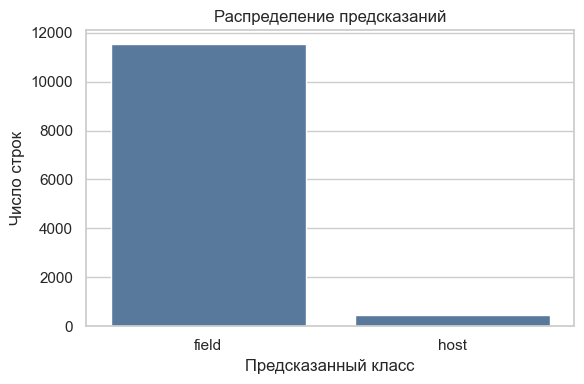

In [5]:
# Распределение предсказаний модели.
prediction_distribution_df = build_prediction_distribution_frame(bundle)
display(
    rename_frame_for_display(
        prediction_distribution_df,
        column_mapping={
            'prediction_label': 'Предсказанный класс',
            'n_rows': 'Число строк',
            'share': 'Доля',
        },
    )
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=prediction_distribution_df,
    x='prediction_label',
    y='n_rows',
    ax=ax,
    color='#4C78A8',
)
ax.set_title('Распределение предсказаний')
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Число строк')
plt.tight_layout()


## Разбор ranking-контура

Если `RANKING_RUN_DIR` не задан, этот раздел можно пропустить.
Если ranking подключен, здесь важно не просто смотреть на красивые значения, а проверять соответствие финальной цели:
- верхушка списка должна быть насыщена целевыми классами `F/G/K/M`;
- `A/B/O` не должны доминировать в `top-N`;
- `evolved` не должны системно забивать верхние позиции;
- `host_similarity` и `observability` должны быть одновременно осмысленными.



In [6]:
# Сводные таблицы для ranking-контура.
if bundle.ranking_df is None:
    print("Артефакты ranking-контура для этого запуска не заданы.")
else:
    priority_distribution_df = build_priority_distribution_frame(bundle)
    goal_alignment_df = build_goal_alignment_frame(bundle, top_n=TOP_N)
    top_candidates_df = build_top_candidates_frame(bundle, top_n=TOP_N)

    display(
        rename_frame_for_display(
            priority_distribution_df,
            column_mapping={
                'priority_label': 'Уровень приоритета',
                'n_rows': 'Число строк',
                'share': 'Доля',
            },
            value_mapping={'priority_label': PRIORITY_LABELS},
        )
    )
    display(
        rename_frame_for_display(
            goal_alignment_df,
            column_mapping={
                'metric_name': 'Показатель',
                'metric_value': 'Значение',
            },
            value_mapping={'metric_name': SCORING_ALIGNMENT_METRIC_LABELS},
        )
    )
    display(top_candidates_df)


,Уровень приоритета,Число строк,Доля
0,Высокий,254,0.021167
1,Низкий,11337,0.944750
2,Средний,409,0.034083


,Показатель,Значение
0,Размер верхнего среза,20.000000
1,Доля целевых классов,1.000000
2,Доля низкоприоритетных классов,0.000000
3,Доля карликов,1.000000
4,Доля эволюционировавших объектов,0.000000
5,Доля высокого приоритета,1.000000
6,Доля среднего приоритета,0.000000
7,Доля низкого приоритета,0.000000
8,Средний host_similarity_score,0.995354
9,Средний observability_score,0.550947


,source_id,spec_class,evolution_stage,priority_score,priority_label,host_similarity_score,observability_score,priority_reason
0,187247281185703296,F,dwarf,0.929964,high,0.999921,0.800000,сильный host-like сигнал; хорошая наблюдательн...
1,2845253659931962368,M,dwarf,0.866669,high,0.999449,0.619762,сильный host-like сигнал
2,5910768975275094784,M,dwarf,0.857479,high,0.999049,0.594021,сильный host-like сигнал
3,6140009865392980224,F,dwarf,0.853325,high,0.999343,0.581774,сильный host-like сигнал
4,3666796481778157696,M,dwarf,0.849400,high,0.999703,0.570096,сильный host-like сигнал
5,6833777856859897984,M,dwarf,0.841479,high,0.986741,0.564129,сильный host-like сигнал
6,3986360121822767872,M,dwarf,0.839612,high,0.999759,0.542058,сильный host-like сигнал
7,5889950993945365632,M,dwarf,0.835561,high,0.994137,0.537713,сильный host-like сигнал
8,3684951411617737088,M,dwarf,0.834426,high,0.999770,0.527228,сильный host-like сигнал
9,5626544360500009344,M,dwarf,0.833739,high,0.995077,0.531297,сильный host-like сигнал


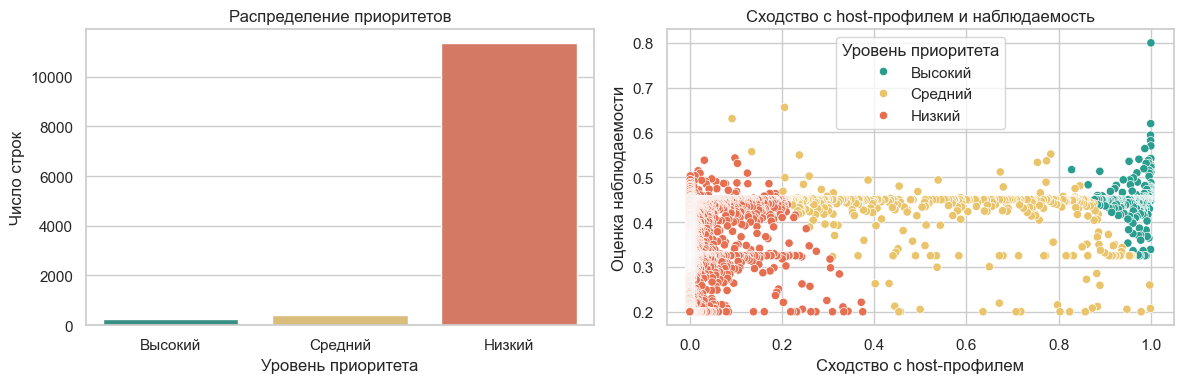

In [7]:
# Визуальная проверка ranking-контура.
if bundle.ranking_df is None:
    print('Артефакты ranking-контура для этого запуска не заданы.')
else:
    priority_plot_df = priority_distribution_df.copy()
    priority_plot_df['priority_label'] = priority_plot_df['priority_label'].map(
        lambda value: PRIORITY_LABELS.get(str(value), str(value))
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(
        data=priority_plot_df,
        x='priority_label',
        y='n_rows',
        hue='priority_label',
        order=[PRIORITY_LABELS['high'], PRIORITY_LABELS['medium'], PRIORITY_LABELS['low']],
        hue_order=[PRIORITY_LABELS['high'], PRIORITY_LABELS['medium'], PRIORITY_LABELS['low']],
        legend=False,
        ax=axes[0],
        palette={
            PRIORITY_LABELS['high']: '#2A9D8F',
            PRIORITY_LABELS['medium']: '#E9C46A',
            PRIORITY_LABELS['low']: '#E76F51',
        },
    )
    axes[0].set_title('Распределение приоритетов')
    axes[0].set_xlabel('Уровень приоритета')
    axes[0].set_ylabel('Число строк')

    if {
        'host_similarity_score',
        'observability_score',
        'priority_label',
    }.issubset(bundle.ranking_df.columns):
        scatter_df = bundle.ranking_df.copy()
        scatter_df['priority_label'] = scatter_df['priority_label'].map(
            lambda value: PRIORITY_LABELS.get(str(value), str(value))
        )
        sns.scatterplot(
            data=scatter_df,
            x='host_similarity_score',
            y='observability_score',
            hue='priority_label',
            palette={
                PRIORITY_LABELS['high']: '#2A9D8F',
                PRIORITY_LABELS['medium']: '#E9C46A',
                PRIORITY_LABELS['low']: '#E76F51',
            },
            ax=axes[1],
        )
        axes[1].set_title('Сходство с host-профилем и наблюдаемость')
        axes[1].set_xlabel('Сходство с host-профилем')
        axes[1].set_ylabel('Оценка наблюдаемости')
        axes[1].legend(title='Уровень приоритета')
    else:
        axes[1].set_visible(False)

    plt.tight_layout()


## Что смотрим в выводе

- Что видно по распределению предсказаний?
- Сколько в `top-N` реально целевых `F/G/K/M` объектов?
- Не перегрет ли `high-priority` за счет низкоприоритетных классов или evolved-стадий?
- Какие источники стоит проверить вручную первыми?

## Следующий шаг

- Если согласование с целью плохое: не тюним все подряд, а сначала смотрим, где именно уходит логика — в model-scoring или в ranking.
- Если согласование с целью хорошее: можно идти в реальный candidate workflow и расширять разметку под subclass-волну.
